In [34]:
from neural_priors.encoding_model.fit_model import get_model, get_paradigm

from neural_priors.utils.data import Subject

In [35]:
subject =  1
model_label = 15
roi = 'NPCr'
bids_folder = '/data/ds-neural_priors'
smoothed = True
fit_responses = True

In [36]:
sub = Subject(subject)

model = get_model(model_label)

data = sub.get_single_trial_estimates(session=None, roi=roi, smoothed=smoothed )

In [37]:
pars = sub.get_prf_parameters_volume(smoothed=smoothed, model_label=model_label, roi=roi, response_fit=fit_responses, raw=True)
paradigm = get_paradigm(sub, fit_responses=fit_responses)

In [38]:

from braincoder.utils import get_rsq
pred = model.predict(paradigm=paradigm, parameters=pars)

residuals = data - pred

# Get the loglikelihood of the data given the model predictions for every voxel separately, assuming Gaussian noise
import numpy as np
from scipy.stats import norm
def log_likelihood(data, pred, sigma):
    return norm.logpdf(data, loc=pred, scale=sigma).sum(0)
sigma = np.std(residuals)
ll = log_likelihood(data, pred, sigma)
print(f'Log-likelihood: {ll}')

Log-likelihood: [-682.5887166  -647.73712087 -522.97959901 -491.454512   -726.4820143
 -587.44084081 -684.43480993 -631.0939188  -522.15494429 -595.10651692
 -677.05443318 -650.88894303 -756.92291256 -627.2653757  -645.15427295
 -738.06759065 -547.40710913 -570.19977981 -532.1133001  -473.53966155
 -611.06135008 -377.08602649 -464.67364804 -444.28533803 -464.71392625
 -396.28375856 -287.00251498 -358.29573646 -422.10190291 -433.37166513
 -391.87857931 -289.54025258 -232.57647976 -532.91715524 -381.14387058
 -470.25407985 -488.26072791 -547.00966754 -432.31627277 -485.3769559
 -848.12314501 -373.27503101 -323.18145003 -393.01268107 -534.13973733
 -659.86545649 -398.30222459 -388.66404252 -299.72708591 -358.68601575
 -429.78401093 -531.46918658 -411.07256478 -290.51801131 -399.76359023
 -304.7173703  -343.65903932 -457.25350363 -552.12531991 -503.99050892
 -317.38946794 -313.54908512 -399.98879987 -217.67339102 -292.61464016
 -253.29462562 -238.29637977 -359.44048331 -234.20497665 -229.8

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [33]:
ll.shape

(771,)

<Axes: xlabel='r2', ylabel='Count'>

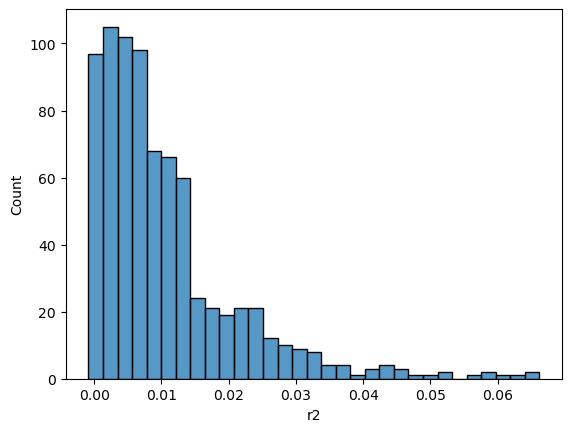

In [28]:
import seaborn as sns
sns.histplot(get_rsq(data, pred))

In [ ]:
model.predict(paradigm=paradigm, parameters=pars)